In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [2]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (133707486152)>


In [5]:
import openseespy.opensees as ops

#Soil Element Properties
elasto_mat_tag = 1
soil_thickness = 1000*UNIT.mm
etype = "PlaneStrain"


# Fixity definitions
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

# Storage for created nodes and elements
created_nodes = []
created_elements = []
block_registry = {}

# Start model
ops.wipe()
ops.model("Basic", "-ndm", 2, "-ndf", 2)

ops.nDMaterial(
            "PressureDependMultiYield02",
            5,
            2, # number of dimension
            17.8, #rho kN /m3 , 1.8*UNIT.ton / UNIT.m3
            9600.0, # ref shear modulus kpa
            27000.0, #ref bulk modulus kPa
            36, # friction angle
            0.1, # peak stress unit less
            101.0, #reference pressure kpa
            0.0, # press Dependent coefficient 
            26, #PT angle
            0.067, # Contrac 1 unit less
            0.23, # Contrac 3 unit less
            0.06, # dilatation 1 unit less
            0.27, # dilatation 3 unit less
            20, #no Yield Surf
            5.0, #Contrac 2 unit less
            3.0, #Contrac 3 unit less
            1.0, # liquefac1
            0.0, # liquefac2
            0.77, # e
            0.9, # cs1
            0.02, # cs2
            0.7, # cs3
            101.0, # pa kPa
        )
        # element thickness
        # body force in x-direction
        # body force in y-direction
        # create wrapper material for initial state analysis
soil_mat_tag = 1
ops.nDMaterial("InitialStateAnalysisWrapper", soil_mat_tag, 5, 2)

    #elasto_mat_tag = 100
    # Define material
    #ops.nDMaterial("ElasticIsotropic", elasto_mat_tag, E, nu, rho)

    # Define contact material
contact_mat = 2
ops.nDMaterial("ContactMaterial2D", contact_mat, 0.1, 1000.0, 0.0, 0.0) #kN/m

# Generate one block starting from node 1 and element 1
node_offset = 0
elem_offset = 1
#node_offset, elem_offset = SF.generate_block(-16, 0.0, 32.0, 12.0, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 2.0, 2.0 ,block_name="OAE_Soil_block")
#node_offset, elem_offset = SF.generate_block(-16, 13.5, 32.0, 4.0, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 1.0, 1.0 ,block_name="OAE_small_block")
node_offset, elem_offset = SF.generate_block(-3.5, 18.0, 7.0, 2.5, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 0.5, 0.5 ,block_name="OAE_little_small_block")
#node_offset, elem_offset = SF.generate_block(0.5, 18.0, 15.5, 2.5, node_offset, elem_offset, etype, soil_mat_tag, soil_thickness, 0.5, 0.5 ,block_name="OAE_little_smalla_block")

InitialStateAnalysisWrapper nDmaterial - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington
ContactMaterial2D nDmaterial - Written: K.Petek, P.Mackenzie-Helnwein, P.Arduino, U.Washington


In [6]:
# start_id = SF.get_next_node_id()
# interface_coor = [
# [0.000 ,  18.000],
# [0.000 ,  19.000],
# [0.000 ,  19.500],
# [0.000 ,  20.000],
# [0.000 ,  20.500],
# ]
# 
# interface_node = SF.add_nodes_from_coordinates(coord_list = interface_coor, start_id = start_id, block_name = "interface_node")

In [7]:
#last_elid = SF.get_next_elem_id(start_from=None)
#right_nodes = [386, 387, 388, 389]
#left_nodes = [257, 289, 321,  353]
#
#quad_patch = SF.create_quad_strip_from_nodes(edge1_nodes = left_nodes, edge2_nodes = right_nodes, 
#                                             start_elem_id = last_elid, thickness = soil_thickness, 
#                                             etype = etype, mat_tag = soil_mat_tag, block_name="quadb_strip")

In [8]:
#last_elid = SF.get_next_elem_id(start_from=None)
#right_nodes = [96, 128, 160, 192]
#left_nodes = [386, 387, 388, 389]
#
#quad_patch = SF.create_quad_strip_from_nodes(edge1_nodes = left_nodes, edge2_nodes = right_nodes, 
#                                             start_elem_id = last_elid, thickness = soil_thickness, 
#                                             etype = etype, mat_tag = soil_mat_tag, block_name="quada_strip")

In [9]:
#start_id = SF.get_next_node_id()
#last_elid = SF.get_next_elem_id(start_from=None)
#slave_coor_node = [
#[ 0.0000 , 18.7000],
#[-0.1414 , 18.6414],
#[-0.2000 , 18.5000],
#[-0.1414 , 18.3586],
#[ 0.0000 , 18.3000],
#[ 0.1414 , 18.3586],
#[ 0.2000 , 18.5000],
#[ 0.1414 , 18.6414],
#]
#
#inter_node_b = [
#[ 0.0000 , 18.8428],
#[-0.2424 , 18.7424],
#[-0.3428 , 18.5000],
#[-0.2424 , 18.2576],
#[ 0.0000 , 18.1572],
#[ 0.2424 , 18.2576],
#[ 0.3428 , 18.5000],
#[ 0.2424 , 18.7424],    
#]
#
#quad_b = SF.create_ring_quads(set_a_coords = inter_node_b, set_b_coords = slave_coor_node, start_node_id = start_id, start_elem_id = last_elid,
#                      thickness = soil_thickness , etype = etype, mat_tag = soil_mat_tag, block_name="ring_quads")

In [10]:
#last_elid = SF.get_next_elem_id(start_from=None)
#right_nodes = [390, 391, 392, 393, 394, 395, 396, 397, 390]
#left_nodes = [386, 96, 64, 32, 385, 193, 225, 257, 386]
#
#quad_patch = SF.create_quad_strip_from_nodes(edge1_nodes = left_nodes, edge2_nodes = right_nodes, 
#                                             start_elem_id = last_elid, thickness = soil_thickness, 
#                                             etype = etype, mat_tag = soil_mat_tag, block_name="quadc_strip")

In [11]:
bot_fixY = SF.fix_nodes_by_range(start_id =2, end_id = 14, step =1, fixity = fixYonly, block_name="fixed_nodes_bottom")
#bot_fixY = SF.fix_nodes_by_range(start_id =193, end_id = 223, step =1, fixity = fixYonly, block_name="fixed_nodes_bottom")
#ops.fix(385, *fixYonly)
ops.fix(1, *fixXY)
ops.fix(15, *fixXY)

In [12]:
eqdof = SF.apply_equal_dof_by_range(
    primary_start =   16 , primary_end = 76, primary_step = 15,
    secondary_start = 30, secondary_end = 90, secondary_step = 15,
    dofs=[1, 2], block_name="equal_dof_constraints")

In [13]:
start_id = SF.get_next_node_id()
LagrangeNB = SF.create_lagrange_nodes(start_id = start_id, x_coord = 2.7552 , y_coord = 20.75, count = 10, block_name="LNB_nodes")

In [14]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [15]:
#start_id = SF.get_next_node_id()
#LagrangeN = SF.create_lagrange_nodes(start_id = start_id, x_coord = 0.75 , y_coord = 18.25, count = 8, block_name="LN_nodes")

In [16]:
#start_id = SF.get_next_node_id()
#interface_coor = [
#[-0.0428 , 18.5555],
#[ 0.0502 , 18.5555],
#[ 0.0502 , 18.4693],
#[-0.0428 , 18.4693],
#]
#
#interface_node = SF.add_nodes_from_coordinates(coord_list = interface_coor, start_id = start_id, block_name = "interface2_node")

In [17]:
#ops.element("quadWithSensitivity", 333, 416, 417, 398, 399, soil_thickness, etype , soil_mat_tag)
#ops.element("quadWithSensitivity", 334, 416, 416, 399, 400, soil_thickness, etype , soil_mat_tag)
#ops.element("quadWithSensitivity", 335, 419, 416, 400, 401, soil_thickness, etype , soil_mat_tag)
#ops.element("quadWithSensitivity", 336, 419, 419, 401, 402, soil_thickness, etype , soil_mat_tag)
#ops.element("quadWithSensitivity", 337, 418, 419, 402, 403, soil_thickness, etype , soil_mat_tag)
#ops.element("quadWithSensitivity", 338, 418, 418, 403, 404, soil_thickness, etype , soil_mat_tag)
#ops.element("quadWithSensitivity", 339, 417, 418, 404, 405, soil_thickness, etype , soil_mat_tag)
#ops.element("quadWithSensitivity", 340, 417, 417, 405, 398, soil_thickness, etype , soil_mat_tag)
#ops.element("quadWithSensitivity", 341, 419, 418, 417, 416, soil_thickness, etype , soil_mat_tag)

In [18]:
ops.model("Basic", "-ndm", 2, "-ndf", 3)

In [19]:
# start_id = SF.get_next_node_id()
# lining_nodes_coor = [
# [ 0.0000 , 18.6000],
# [-0.0707 , 18.5707],
# [-0.1000 , 18.5000],
# [-0.0707 , 18.4293],
# [ 0.0000 , 18.4000],
# [ 0.0707 , 18.4293],
# [ 0.1000 , 18.5000],
# [ 0.0707 , 18.5707],
# ]
# 
# lining_noodes = SF.add_nodes_from_coordinates(coord_list = lining_nodes_coor, start_id = start_id, block_name = "lining_nodes")

In [20]:
Iz = SF.FormRectangularInertia(b = 1.0, h = 0.02)
print(Iz)

6.666666666666668e-07


In [21]:
# lining_noodes = lining_noodes + [424]
transFTag = 1
# beam_secTag = 1
# intTag = 401
# Nint = 3
# 
# # Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
# ops.section("Elastic", beam_secTag, 200*UNIT.gpa, 0.02*UNIT.m2, Iz*UNIT.m4)
# ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)
# 
# BEAM = SF.create_disp_beam_column_chain(beam_nodes = lining_noodes, beam_start_id = 5000,
#                                    transFTag = transFTag, intTag = intTag,
#                                    block_name="beam_chain") 

In [22]:
#lining_slave_nodes = [398, 399, 400, 401, 402, 403, 404, 405]

In [23]:
# CONTACT_A = SF.create_beam_contact_chain(master_nodes = lining_noodes, slave_nodes = lining_slave_nodes, lagrange_nodes = LagrangeN,
#                                contact_mat = contact_mat, beam_start_id = 3050,
#                                width=1000*UNIT.mm, tol1=1e-10, tol2=1e-10,
#                                block_name="contact_beams")

In [24]:
start_id = SF.get_next_node_id()
pad_nodes_coor = [
[ 2.2985 , 20.7500],
[ 1.7985 , 20.7500],
[ 1.2985 , 20.7500],
[ 0.7985 , 20.7500],
[ 0.2985 , 20.7500],
[-0.2015 , 20.7500],
[-0.7015 , 20.7500],
[-1.2015 , 20.7500],
[-1.7015 , 20.7500],
[-2.2015 , 20.7500],
]

pad_nodes = SF.add_nodes_from_coordinates(coord_list = pad_nodes_coor, start_id = start_id, block_name = "pad_nodes_coor")

In [25]:
Iza = SF.FormRectangularInertia(b = 1.0, h = 0.3)
pad_nodes = pad_nodes + []
beam_secTag = 2
intTag = 402
Nint = 3

# Geometry transformation and section definition

ops.section("Elastic", beam_secTag, 200*UNIT.gpa, 0.3*UNIT.m2, Iza*UNIT.m4)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

BEAM = SF.create_disp_beam_column_chain(beam_nodes = pad_nodes, beam_start_id = 900,
                                   transFTag = transFTag, intTag = intTag,
                                   block_name="beam_chain") 

In [26]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [27]:
pad_slave_nodes = [87, 86, 85, 84, 83, 82, 81, 80, 79]

In [28]:
CONTACT_C = SF.create_beam_contact_chain(master_nodes = pad_nodes, slave_nodes = pad_slave_nodes, lagrange_nodes = LagrangeNB,
                               contact_mat = contact_mat, beam_start_id = 4050,
                               width=1000*UNIT.mm, tol1=1e-10, tol2=1e-10,
                               block_name="contact_beams")

BeamContact2D element - Written: C.McGann, P.Arduino, P.Mackenzie-Helnwein, U.Washington


In [29]:
ops.fix(110, 0, 1, 0)
ops.fix(101, 0, 1, 0)

In [30]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [31]:
OPSVIS = opst.vis.pyvista

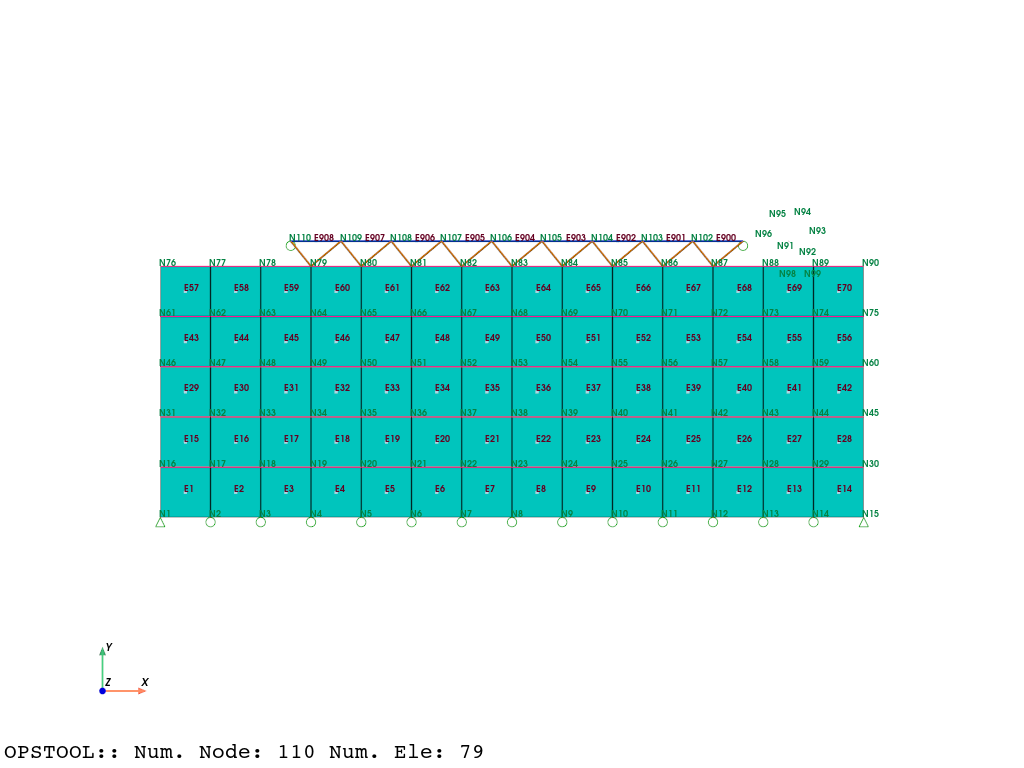

In [32]:
OPSVIS.set_plot_props(point_size=1, font_size=9, notebook=True)
OPSVIS.plot_model(show_node_numbering=True, show_ele_numbering=True).show(jupyter_backend="jupyterlab")

In [33]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    model_update=True,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",
)

In [34]:
# define analysis parameters for gravity phase
ops.constraints("Transformation")
ops.test("NormDispIncr", 1e-05, 50, 0)
ops.algorithm("Newton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [35]:
# turn on initial state analysis feature
ops.InitialStateAnalysis("on")
# ensure soil material intially considers linear elastic behavior
ops.updateMaterialStage("-material", 1, "-stage", 0)
# set contact elements to be frictionless for gravity analysis
#ops.setParameter("-val", 0, "-eleRange", 3050, 3057, "friction")
ops.setParameter("-val", 0, "-eleRange", 4050, 4058, "friction")
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()

InitialStateAnalysis ON
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenL

In [36]:
# update soil material to consider elastoplastic behavior and analyze a few more steps
ops.updateMaterialStage("-material", 1, "-stage", 1)
# analysis 4 steps, and fetch response
for _ in range(4):
    ops.analyze(1)
    ODB.fetch_response_step()
# designate end of initial state analysis (zeros displacements, keeps state variables)
ops.InitialStateAnalysis("off")
# turn on frictional behavior for beam contact elements
#ops.setParameter("-val", 0, "-eleRange", 3050, 3057, "friction")
ops.setParameter("-val", 0, "-eleRange", 4050, 4058, "friction")

WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() 

In [37]:
# define analysis parameters for excavation phase
# define analysis parameters for excavation phase
ops.wipeAnalysis()
ops.constraints("Transformation")
ops.test("NormDispIncr", 0.0001, 60)
ops.algorithm("KrylovNewton")
ops.numberer("RCM")
ops.system("BandGeneral")
ops.integrator("LoadControl", 1)
ops.analysis("Static")

In [38]:
def remove_components(ele_tags, node_tags, nsteps=4):
    for etag in ele_tags:
        ops.remove("element", etag)
    for ntag in node_tags:
        ops.remove("node", ntag)
    # run analysis after object removal
    for _ in range(nsteps):
        ops.analyze(1)
        ODB.fetch_response_step()

In [39]:
PN_1 = 5000*UNIT.N
print(PN_1)

5.0


In [40]:
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
ops.load(105, 0, -PN_1, 0)

In [41]:
ops.analyze(1)

WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() 

-3

In [42]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 1 removed")

WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() 

Lift 1 removed


WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() 

In [43]:
PN_2 = 5000*UNIT.N
print(PN_2)

5.0


In [44]:
ops.load(106, 0, -PN_2, 0)

In [45]:
ops.analyze(1)

WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() 

-3

In [46]:
# remove objects associated with lift 1
# soil elements
ele_tags = []
ele_tags += []  # contact element
# soil nodes
node_tags = []
node_tags += []  # lagrange multiplier node

remove_components(ele_tags, node_tags, nsteps=4)

print("Lift 2 removed")

WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() -factorization failed, matrix singular U(i,i) = 0, i= 0
WARNING BandGenLinLapackSolver::solve() 

Lift 2 removed


In [47]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=True, show_nodal_loads = True)

In [48]:
ODB.save_response(zlib=True)

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [49]:
import matplotlib.pyplot as plt

import opstool as opst
import opstool.vis.pyvista as opsvis

In [50]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

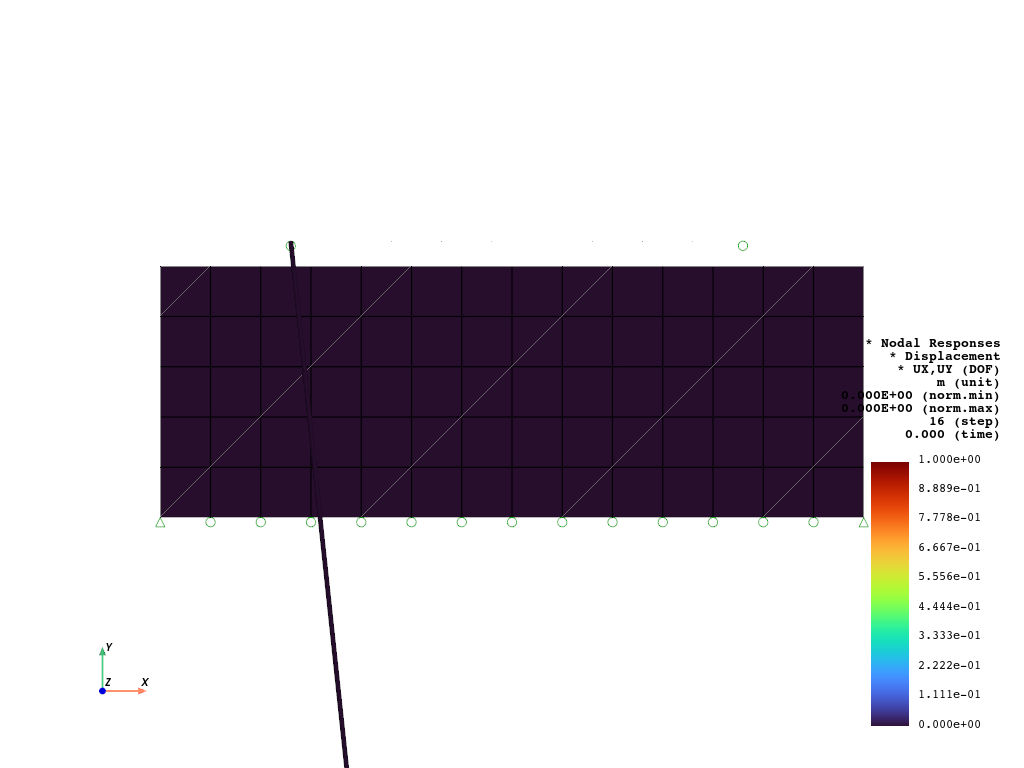

: 

In [ ]:
opsvis.plot_nodal_responses(
    odb_tag=1,
    slides=True,
    scale=2,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="juoyterlab")

In [ ]:
opsvis.plot_nodal_responses_animation(
    odb_tag=1,
    framerate=2,
    scale=2,
    savefig="NodalRespAnimationA.gif",
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

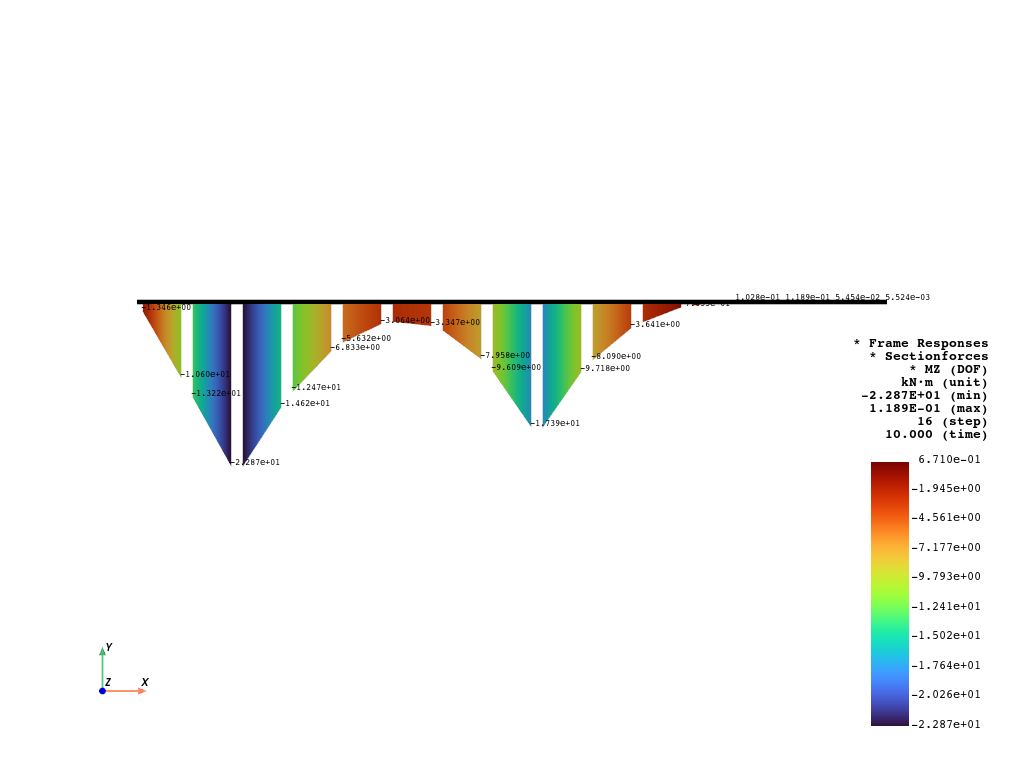

In [ ]:
plotter = opsvis.plot_frame_responses(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    unit_symbol="kN·m",
    show_values="eleMaxMin",
    scale=3,
    slides=True,
    style="surface",
    show_model=False,  # plot all model
    opacity=1.0,
    show_bc=False,
)
plotter.show(jupyter_backend="jupyterlab")

In [ ]:
opsvis.plot_frame_responses_animation(
    odb_tag=1,
    resp_type="sectionForces",
    resp_dof="MZ",
    framerate=2,
    scale=3,
    line_width=4,
    savefig="FrameForcesMZ_A.gif",
).close()

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

Animation has been saved as FrameForcesMZ_A.gif!


OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

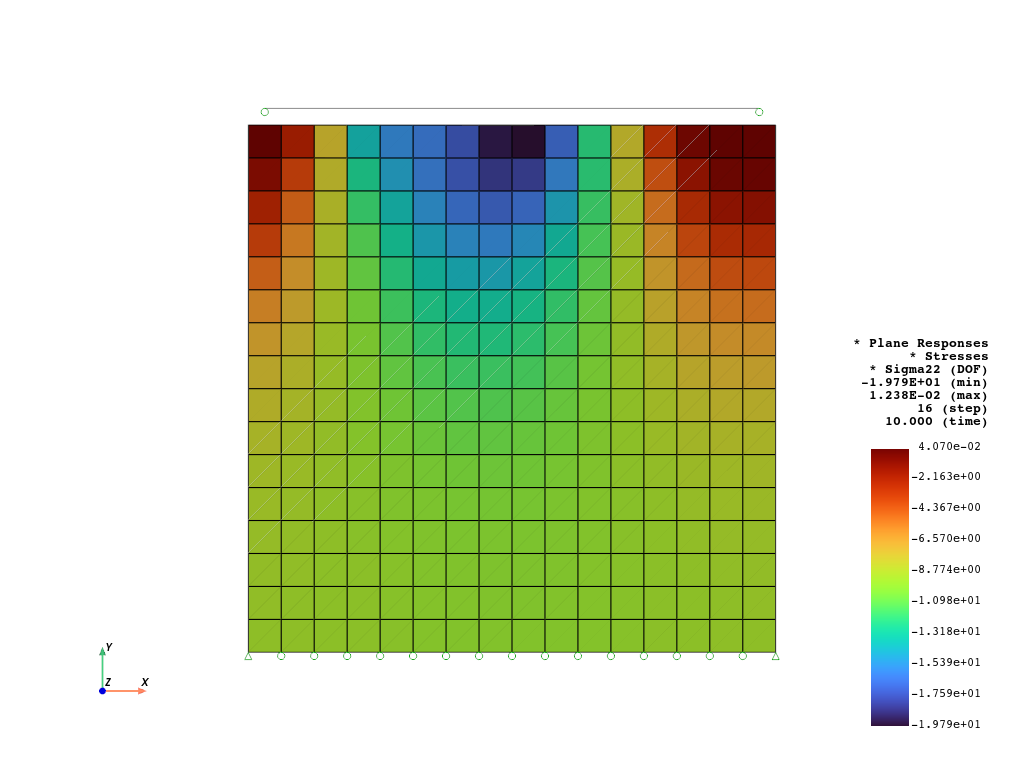

In [ ]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma22"
).show(jupyter_backend="jupyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-1.nc ...

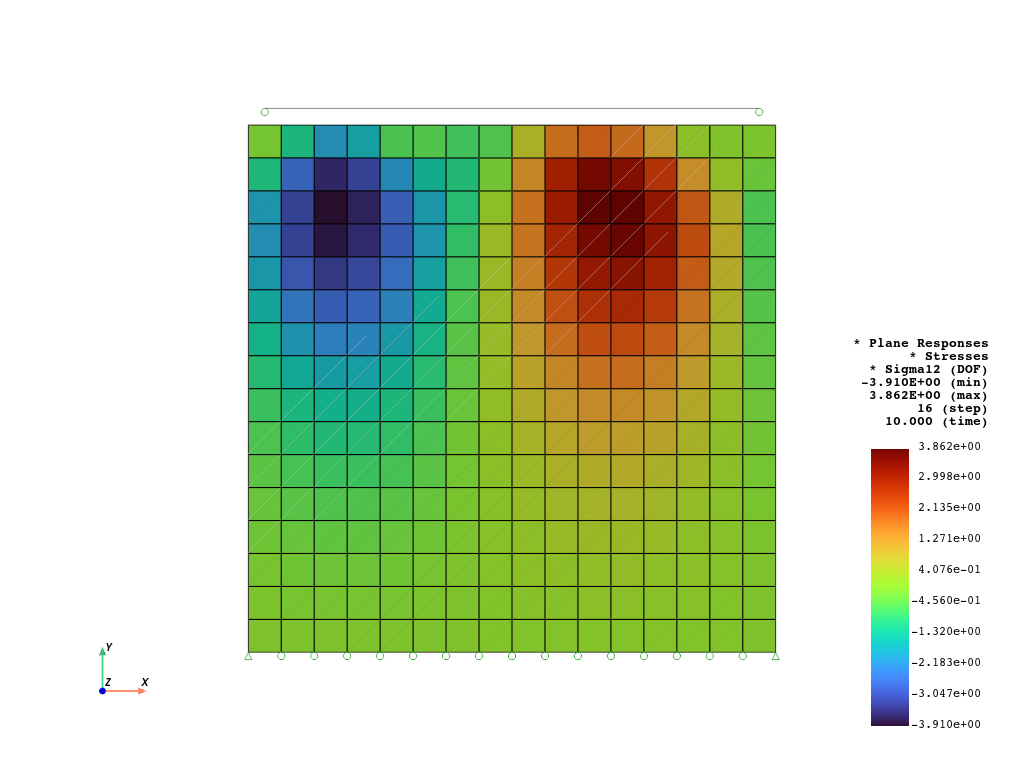

In [ ]:
opsvis.plot_unstruct_responses(
    odb_tag=1, slides=True, ele_type="Plane", resp_type="Stresses", resp_dof="sigma12"
).show(jupyter_backend="jupyterlab")

In [ ]:
data = opst.post.get_element_responses(odb_tag=1, ele_type="Contact")

OPSTOOL ::  Loading Contact response data from .opstool.output/RespStepData-1.nc ...

In [ ]:
print(data)

<xarray.Dataset> Size: 11kB
Dimensions:       (time: 17, eleTags: 15, globalDOFs: 3, localDOFs: 3,
                   slipDOFs: 2)
Coordinates:
  * eleTags       (eleTags) int64 120B 3050 3051 3052 3053 ... 3062 3063 3064
  * globalDOFs    (globalDOFs) <U2 24B 'Px' 'Py' 'Pz'
  * localDOFs     (localDOFs) <U2 24B 'N' 'Tx' 'Ty'
  * slipDOFs      (slipDOFs) <U2 16B 'Tx' 'Ty'
  * time          (time) float32 68B 0.0 1.0 2.0 3.0 4.0 ... 7.0 8.0 9.0 10.0
Data variables:
    globalForces  (time, eleTags, globalDOFs) float32 3kB -0.0 -0.0 ... -0.0 0.0
    localForces   (time, eleTags, localDOFs) float32 3kB 0.0 0.0 0.0 ... 0.0 0.0
    localDisp     (time, eleTags, localDOFs) float32 3kB 0.0 0.0 0.0 ... 0.0 0.0
    slips         (time, eleTags, slipDOFs) float32 2kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    Px:       Global force in the x-direction on the constrained node
    Py:       Global force in the y-direction on the constrained node
    Pz:       Global force in the z-direction on the con

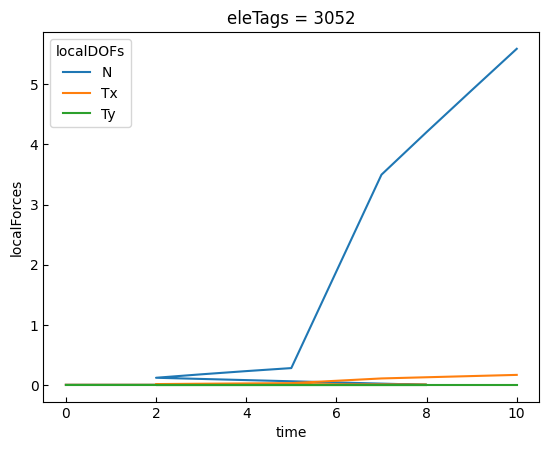

In [ ]:
data["localForces"].sel(eleTags=3052).plot.line(x="time")
plt.show()

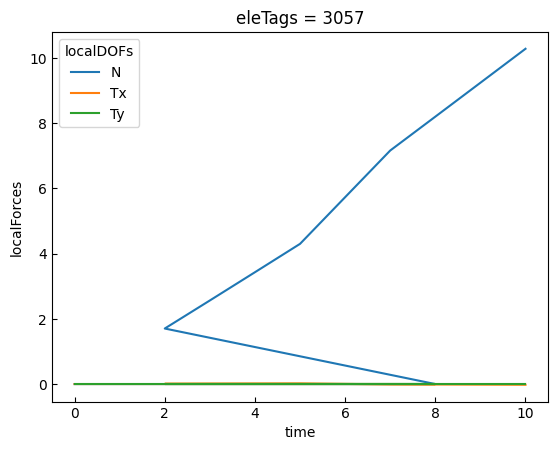

In [ ]:
data["localForces"].sel(eleTags=3057).plot.line(x="time")
plt.show()

In [ ]:
data["localForces"].sel(eleTags=3057).data

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.70275807e+00,  7.50111509e-03,  0.00000000e+00],
       [ 2.56310129e+00,  1.11055970e-02,  0.00000000e+00],
       [ 3.42931175e+00,  1.46410568e-02,  0.00000000e+00],
       [ 4.29914141e+00,  1.81224756e-02,  0.00000000e+00],
       [ 7.16109800e+00, -9.21798684e-03,  0.00000000e+00],
       [ 8.19898701e+00, -1.36231985e-02,  0.00000000e+00],
       [ 9.23911953e+00, -1.79754198e-02,  0.00000000e+00],
       [ 1.02803564e+01, -2.22930573e-02

In [ ]:
data["localDisp"].sel(eleTags=3057).data

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)

In [ ]:
data_frame = opst.post.get_element_responses(odb_tag=1, ele_type="Frame")

OPSTOOL ::  Loading Frame response data from .opstool.output/RespStepData-1.nc ...

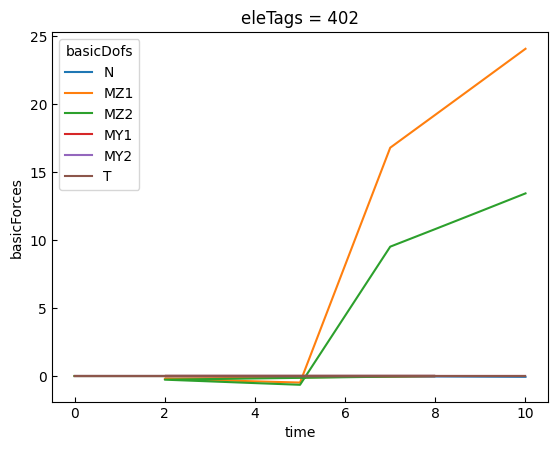

In [ ]:
data_frame["basicForces"].sel(eleTags=402).plot.line(x="time")
plt.show()

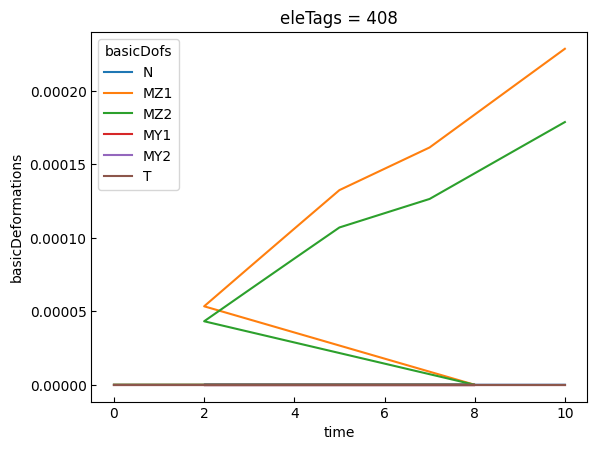

In [ ]:
data_frame["basicDeformations"].sel(eleTags=408).plot.line(x="time")
plt.show()